<a href="https://colab.research.google.com/github/rowanmacy/text-classifier/blob/main/Problem_1_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import os
import textwrap

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

from scipy.stats import uniform

In [ ]:
# TODOs

# Normalization
# Random state
# Elastic net l1 penalty
# Fit transform/how do we get the vocabulary out of the fit?
# Swap AUCROC to accuracy and see what happens

In [2]:
# Clone repo
!rm -rf /content/text-classifier  # clear any existing clone
!git clone "https://github.com/rowanmacy/text-classifier/"  # clone repo

Cloning into 'text-classifier'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 107 (delta 38), reused 29 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 31.66 MiB | 16.66 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [3]:
# Check repo contents
!ls /content/text-classifier/starter_code/data_readinglevel/

x_test_BERT_embeddings.npz  x_train_BERT_embeddings.npz  y_train.csv
x_test.csv		    x_train.csv


## Read in data

In [4]:
# Read in training data
x_train_df = pd.read_csv("/content/text-classifier/starter_code/data_readinglevel/x_train.csv")
y_train_df = pd.read_csv("/content/text-classifier/starter_code/data_readinglevel/y_train.csv")
x_test_df = pd.read_csv("/content/text-classifier/starter_code/data_readinglevel/x_test.csv")

In [5]:
# Extract text information from x_train_df and x_test_df
tr_text_list = x_train_df['text'].values.tolist()
te_text_list = x_test_df['text'].values.tolist()

In [6]:
# Convert y_train_df into binary classification array
# Turn y_train data into binary classification
y_train_df['Class'] = (y_train_df['Coarse Label'] == 'Key Stage 4-5').astype(int)
y_dev = np.asarray(y_train_df['Class'])

## Pre-defined split for proxy test set (validation)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(tr_text_list, y_dev, test_size=0.2, random_state=42, shuffle=True)

In [8]:
len(X_train)

4445

## Set up pipeline

In [9]:
# Define pipeline for preprocessing and classifier
problem_1_pipeline = Pipeline([
    ('problem_1_preprocessor', CountVectorizer(lowercase=True, strip_accents='ascii')),
     ('problem_1_model', LogisticRegression(max_iter=500, random_state=101, penalty='l2')),
])

In [29]:
# Define total possible vocabulary
vocab_vectorizer = CountVectorizer(lowercase=True, strip_accents='ascii')
vocab_vectorizer.fit(X_train)
max_features_total = len(vocab_vectorizer.vocabulary_)
print(max_features_total)

24640


## Create RandomizedSearchCV

In [30]:
# Define hyperparameter grid to search and scoring metric
distributions = dict()

# Preprocessing hyperparameters
distributions['problem_1_preprocessor__min_df'] = np.linspace(0.01, 0.04, 100)
distributions['problem_1_preprocessor__max_df'] = np.linspace(0.6, 1.0, 100)
distributions['problem_1_preprocessor__max_features'] = np.linspace(int(0.6 * max_features_total), int(0.8 * max_features_total), 100).astype(np.int_)
#distributions['problem_1_preprocessor__binary'] = [False, True]

# Model parameters
distributions['problem_1_model__C'] = np.logspace(-6, 6, 1000)
#distributions['problem_1_model__l1_ratio'] = np.linspace(0, 1, 5)

scoring_metric = 'roc_auc'

In [31]:
# Define RandomizedSearchCV and fit to training data
random_searcher = RandomizedSearchCV(
    problem_1_pipeline,
    distributions,
    n_iter=100,  # increases number of parameter combinations tried
    scoring=scoring_metric,
    cv=KFold(n_splits=10, shuffle=True), # Always good to shuffle
    refit=True, # Automatically retrain the best-performing model on all available data
    verbose = 1,
    # random_state=101,
    error_score = 'raise')

In [13]:
# Fit random_searcher object to training data
random_searcher.fit(X_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


RandomizedSearchCV(cv=KFold(n_splits=10, random_state=None, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(steps=[('problem_1_preprocessor',
                                              CountVectorizer(strip_accents='ascii')),
                                             ('problem_1_model',
                                              LogisticRegression(max_iter=500,
                                                                 random_state=101))]),
                   n_iter=100,
                   param_distributions={'problem_1_model__C': array([1.00000000e-06, 1.02804473e-06, 1.05...
       0.03121212, 0.03151515, 0.03181818, 0.03212121, 0.03242424,
       0.03272727, 0.0330303 , 0.03333333, 0.03363636, 0.03393939,
       0.03424242, 0.03454545, 0.03484848, 0.03515152, 0.03545455,
       0.03575758, 0.03606061, 0.03636364, 0.03666667, 0.0369697 ,
       0.03727273, 0.03757576, 0.03787879, 0.03818182, 0.03848485,
       0.03878788, 0.03909091, 0.03939394, 0.03969697, 0.04      ])},
                   scoring='roc_auc', verbose=1)

In [14]:
# Print result of search
problem_1_hyp_results = pd.DataFrame(random_searcher.cv_results_).copy()
param_keys = ['param_'+str(key) for key in random_searcher.best_params_.keys()]

# Rearrange row order
problem_1_hyp_results.sort_values(param_keys, inplace=True)

# Visualize
problem_1_hyp_results[param_keys + ['mean_test_score', 'rank_test_score']]

,param_problem_1_preprocessor__min_df,param_problem_1_preprocessor__max_features,param_problem_1_preprocessor__max_df,param_problem_1_model__C,mean_test_score,rank_test_score
44,0.010303,18069,0.729293,69.798139,0.691300,97
22,0.010606,18616,0.834343,109405.470721,0.692024,95
28,0.010606,19363,0.628283,13369.837418,0.692021,96
75,0.010909,16078,0.846465,25.787629,0.693944,91
62,0.011515,15132,0.701010,914.031075,0.695972,84
...,...,...,...,...,...,...
29,0.038182,18965,0.842424,0.000030,0.694231,90
19,0.038182,19463,0.656566,0.000013,0.693935,92
60,0.039091,18965,0.684848,23.734243,0.707105,55
50,0.039394,15630,0.911111,0.633580,0.709206,39


In [15]:
# Find minimum, maximum, median, and mean of vocabulary set size
print(problem_1_hyp_results['param_problem_1_preprocessor__max_features'].min())
print(problem_1_hyp_results['param_problem_1_preprocessor__max_features'].max())
print(int(problem_1_hyp_results['param_problem_1_preprocessor__max_features'].mean()))

14784
19662
17167


In [16]:
# Capture best hyperparameters
problem_1_params = random_searcher.best_params_

for param, value in problem_1_params.items():
  print(param, ':', value)

problem_1_preprocessor__min_df : 0.014242424242424242
problem_1_preprocessor__max_features : 18168
problem_1_preprocessor__max_df : 0.9353535353535354
problem_1_model__C : 0.009727203192450537


## Make predictions and plot ROC curve

In [17]:
# Evaluate performance on training and validation data
yhat_tr = random_searcher.predict_proba(X_train)[:,1]
yhat_val = random_searcher.predict_proba(X_val)[:,1]

# Calculate AUROC for training and validation predictions
roc_auc_tr = roc_auc_score(y_train, yhat_tr)
roc_auc_val = roc_auc_score(y_val, yhat_val)
print('Training score:', round(roc_auc_tr, 5))
print('Validation score:', round(roc_auc_val, 5))

Training score: 0.78211
Validation score: 0.73823


In [18]:
# Print confusion matrices at 50% threshold
print('Training CF:\n', confusion_matrix(y_train, yhat_tr >= 0.5))
print('\nValidation CF:\n', confusion_matrix(y_val, yhat_val >= 0.5))

Training CF:
 [[1201  809]
 [ 483 1952]]

Validation CF:
 [[290 209]
 [142 471]]


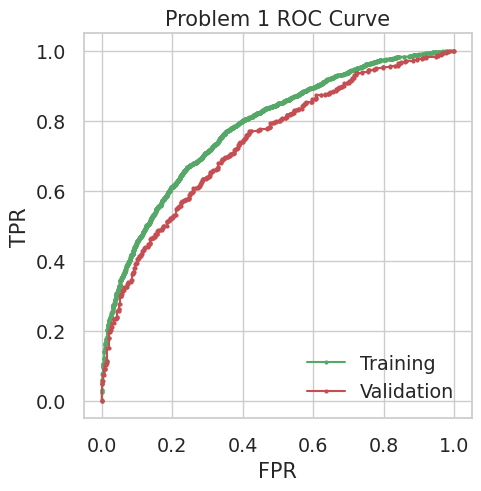

In [19]:
# Print ROC curves
tr_fpr, tr_tpr, tr_thresholds = roc_curve(y_train, yhat_tr)
val_fpr, val_tpr, val_thresholds = roc_curve(y_val, yhat_val)

plt.figure(figsize=(5,5))
plt.plot(tr_fpr, tr_tpr, 'g.-', label='Training')
plt.plot(val_fpr, val_tpr, 'r.-', label='Validation')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Problem 1 ROC Curve')
plt.legend(loc='lower right')

## Create graphic for hyperparameter selection of 'min_df'

In [20]:
# Generate range of values for C and initialize AUROC score dictionaries
C_range = np.logspace(-6, 3, 20)
tr_AUROC = {}
val_AUROC = {}

In [21]:
# Loop through values of min_df and calculate training and validation scores for 5 folds
kf = KFold(n_splits=5)
kf.get_n_splits()
tr_text_list = np.array(tr_text_list)

for i, (train_idx, val_idx) in enumerate(kf.split(tr_text_list)):
  X_train_fold = tr_text_list[train_idx]
  X_val_fold = tr_text_list[val_idx]
  y_train_fold = y_dev[train_idx]
  y_val_fold = y_dev[val_idx]

  tr_AUROC[i] = {}
  val_AUROC[i] = {}

  for C in C_range:
    problem_1_hyp_pipeline = Pipeline([
    ('problem_1_preprocessor', CountVectorizer(lowercase=True, strip_accents='ascii', max_df=problem_1_params['problem_1_preprocessor__max_df'], max_features=problem_1_params['problem_1_preprocessor__max_features'], min_df=problem_1_params['problem_1_preprocessor__min_df'])),
    ('problem_1_model', LogisticRegression(max_iter=500, random_state=101, penalty='l2', C=C))])

    # Fit to training data
    problem_1_hyp_pipeline.fit(X_train_fold, y_train_fold)

    # Predict on training and validation sets
    yhat_tr = problem_1_hyp_pipeline.predict_proba(X_train_fold)[:,1]
    yhat_val = problem_1_hyp_pipeline.predict_proba(X_val_fold)[:,1]

    # Calculate and append AUROC scores
    tr_AUROC[i][C] = roc_auc_score(y_train_fold, yhat_tr)
    val_AUROC[i][C] = roc_auc_score(y_val_fold, yhat_val)


In [22]:
# Calculate mean
mean_tr_AUROC = {}
mean_val_AUROC = {}

for C in C_range:
  tr_sum = 0
  val_sum = 0
  for i in range(5):
    tr_sum += tr_AUROC[i][C]
    val_sum += val_AUROC[i][C]
  mean_tr_AUROC[C] = tr_sum / 5
  mean_val_AUROC[C] = val_sum /5


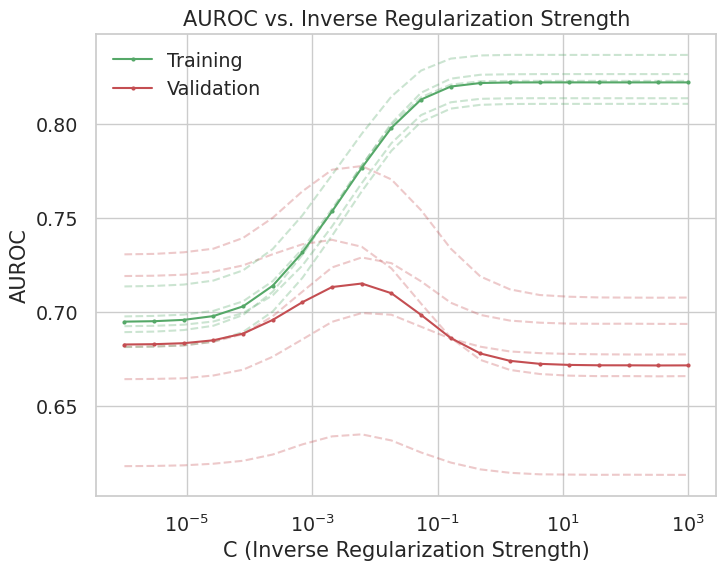

In [23]:
# Plot training and validation AUROC vs. value of min_df
plt.figure(figsize=(8,6))
for i in range(5):
  plt.plot(C_range, tr_AUROC[i].values(), 'g--', alpha=0.3)
  plt.plot(C_range, val_AUROC[i].values(), 'r--', alpha=0.3)
plt.plot(C_range, mean_tr_AUROC.values(), 'g.-', label='Training')
plt.plot(C_range, mean_val_AUROC.values(), 'r.-', label='Validation')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('AUROC')
plt.title('AUROC vs. Inverse Regularization Strength')
plt.legend()
plt.xscale('log')

## Save results to files

In [ ]:
#file = open('parameter_iterations.txt', 'x')

In [ ]:
# Save parameters to text file
with open('parameter_iterations.txt', "a") as f:
  for param, value in problem_1_params.items():
    f.write('\n' + str(param) + ': ' + str(value))
  f.write('\n\nTraining score: ' + str(round(roc_auc_tr, 3)))
  f.write('\n\n')

In [ ]:
# Make predictions on test data
yhat_te = random_searcher.predict_proba(te_text_list)[:,1]

In [ ]:
# Delete previous file
os.remove('yproba1_test.txt')

In [ ]:
# Save results to .txt file
file = open('yproba1_test.txt', "x")

with open('yproba1_test.txt', "w") as f:
    f.write('\n'.join(yhat_te.astype('str')))

## Compare to normalized version

In [35]:
# Define pipeline for preprocessing and classifier, including normalizer step
problem_1_pipeline_normal = Pipeline([
    ('problem_1_preprocessor', CountVectorizer(lowercase=True, strip_accents='ascii')),
     ('problem_1_normalizer', Normalizer()),
     ('problem_1_model', LogisticRegression(max_iter=500, random_state=101, penalty='l2')),
])

# Define RandomizedSearchCV and fit to training data
random_searcher_normal = RandomizedSearchCV(
    problem_1_pipeline_normal,
    distributions,
    n_iter=100,  # increases number of parameter combinations tried
    scoring=scoring_metric,
    cv=KFold(n_splits=10, shuffle=True), # Always good to shuffle
    refit=True, # Automatically retrain the best-performing model on all available data
    verbose = 1,
    # random_state=101,
    error_score = 'raise')

# Fit random_searcher object to training data
random_searcher_normal.fit(X_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


RandomizedSearchCV(cv=KFold(n_splits=10, random_state=None, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(steps=[('problem_1_preprocessor',
                                              CountVectorizer(strip_accents='ascii')),
                                             ('problem_1_normalizer',
                                              Normalizer()),
                                             ('problem_1_model',
                                              LogisticRegression(max_iter=500,
                                                                 random_state=101))]),
                   n_iter=100,
                   param_distributions={'problem_1_model__C': arr...
       0.03121212, 0.03151515, 0.03181818, 0.03212121, 0.03242424,
       0.03272727, 0.0330303 , 0.03333333, 0.03363636, 0.03393939,
       0.03424242, 0.03454545, 0.03484848, 0.03515152, 0.03545455,
       0.03575758, 0.03606061, 0.03636364, 0.03666667, 0.0369697 ,
       0.03727273, 0.03757576, 0.03787879, 0.03818182, 0.03848485,
       0.03878788, 0.03909091, 0.03939394, 0.03969697, 0.04      ])},
                   scoring='roc_auc', verbose=1)

In [45]:
# Evaluate performance of normalized model
# Print result of search
problem_1_hyp_results_normal = pd.DataFrame(random_searcher_normal.cv_results_).copy()
param_keys_normal = ['param_'+str(key) for key in random_searcher_normal.best_params_.keys()]

# Rearrange row order
problem_1_hyp_results_normal.sort_values(param_keys_normal, inplace=True)

# Visualize
problem_1_hyp_results_normal[param_keys_normal + ['mean_test_score', 'rank_test_score']]

# Find minimum, maximum, median, and mean of vocabulary set size
print(problem_1_hyp_results_normal['param_problem_1_preprocessor__max_features'].min())
print(problem_1_hyp_results_normal['param_problem_1_preprocessor__max_features'].max())
print(int(problem_1_hyp_results_normal['param_problem_1_preprocessor__max_features'].mean()))

# Capture best hyperparameters
problem_1_params_normal = random_searcher_normal.best_params_

for param, value in problem_1_params_normal.items():
  print(param, ':', value)

14784
19712
17383
problem_1_preprocessor__min_df : 0.013939393939393939
problem_1_preprocessor__max_features : 15978
problem_1_preprocessor__max_df : 0.6363636363636364
problem_1_model__C : 1.1643031329208755


In [46]:
# Evaluate performance on training and validation data
yhat_tr_normal = random_searcher_normal.predict_proba(X_train)[:,1]
yhat_val_normal = random_searcher_normal.predict_proba(X_val)[:,1]

# Calculate AUROC for training and validation predictions
roc_auc_tr_normal = roc_auc_score(y_train, yhat_tr_normal)
roc_auc_val_normal = roc_auc_score(y_val, yhat_val_normal)
print('Training score:', round(roc_auc_tr, 5))
print('Validation score:', round(roc_auc_val, 5))
# same as not normalized?

Training score: 0.78211
Validation score: 0.73823


In [47]:
# Print confusion matrices at 50% threshold
print('Training CF:\n', confusion_matrix(y_train, yhat_tr_normal >= 0.5))
print('\nValidation CF:\n', confusion_matrix(y_val, yhat_val_normal >= 0.5))
# quite different

Training CF:
 [[1285  725]
 [ 545 1890]]

Validation CF:
 [[294 205]
 [174 439]]


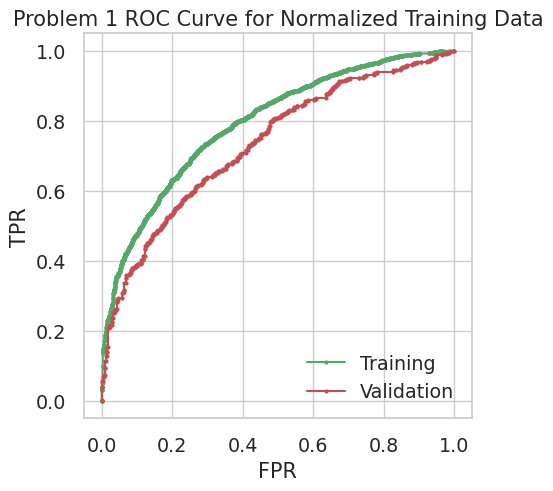

In [48]:
# Print ROC curves
tr_fpr_normal, tr_tpr_normal, tr_thresholds_normal = roc_curve(y_train, yhat_tr_normal)
val_fpr_normal, val_tpr_normal, val_thresholds_normal = roc_curve(y_val, yhat_val_normal)

plt.figure(figsize=(5,5))
plt.plot(tr_fpr_normal, tr_tpr_normal, 'g.-', label='Training')
plt.plot(val_fpr_normal, val_tpr_normal, 'r.-', label='Validation')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Problem 1 ROC Curve for Normalized Training Data')
plt.legend(loc='lower right')

## ARCHIVE

In [ ]:
# Create CountVectorizer object
# TODO: min_df, max_df, binary
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(tr_text_list)
vectorizer.get_feature_names_out()
vocab_list = vectorizer.vocabulary_

In [ ]:
# Fit logistic regression model to training data
clf.fit(X_train, y_train)

In [ ]:
# Convert test data into vector
X_test_list = x_test_df['text'].values.tolist()
V = len(x_test_df)

In [ ]:
# Make predictions on test vector
yhat_test = []

for passage in X_test_list:
  x_V = vectorizer.transform([passage])
  #print(x_V.shape)
  prediction = clf.predict_proba(x_V.reshape((1,26866)))

  with open('yproba1_test.txt', 'a') as f:
    f.write(prediction[0][1].astype('str')+'\n')

  print('Prediction:', prediction[0][1])


In [ ]:
# Cross-validate
# Hyperparameter values
C_grid = np.logspace(-4, 4, 17)
k_grid = range(1, 18)

# Create development dataset

# Split data for CV
SEED = 12345

# Use K-fold to perform cross-validation
K = 10
kf = sklearn.model_selection.KFold(n_splits=K, shuffle=True, random_state=SEED)

# Train models with desired degree, alpha, K-fold
for c_ind, c in enumerate(C_grid):
        for k, (train_ind, val_ind) in enumerate(kf.split(X_train, y_train)):
            #print(f"fold {k}")
            model = sklearn.Pipeline([
                # TODO: call pipeline defined earlier
                ])
            #print(f"model defined")
            # Train the model
            model.fit(X_train[train_ind], y_train[train_ind])

            # Make predictions on validation data
            yhat_L = model.predict(X_train[val_ind])  #removed sanitize step since it's not defined in this notebook

            print(f"C {c}, K {k}, AUCROC")
            # TODO: compute AUCROC


In [ ]:
# Define preprocessor
def build_preprocessor():
  preprocessor = Pipeline([
      ('vectorizer', CountVectorizer(
       lowercase=True  # make everything lowercase
       #strip_accents='ascii',
       #stop_words='english'  # remove stop words
      ))
  ])
  return preprocessor

# Process data
preprocessor = build_preprocessor()
x_train_processed = preprocessor.fit_transform(x_train_df['text'])
max_features_total = x_train_processed.shape[1]